In [40]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [4]:
# Set visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load the dataset

In [5]:
df = pd.read_csv('Loan_Default.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (148670, 34)


* We have a total of 34 features of 1,48,670 rows

# Features :

- **ID** = Unique identifier for each loan record.

- **year** = Year in which the loan was issued.

- **loan_limit** = Indicates whether the loan exceeds a predefined lending limit.

- **Gender** = Gender of the primary loan applicant.

- **approv_in_adv** = Whether the loan was approved in advance (pre-approved) or not.

- **loan_type** = Type/category of the loan (e.g., conventional, government-backed).

- **loan_purpose** = Purpose for which the loan was taken (e.g., purchase, refinance).

- **Credit_Worthiness** = Assessment category of the applicant’s credit quality.

- **open_credit** = Indicates if the applicant currently has open lines of credit.

- **business_or_commercial** = Whether the loan is for business/commercial use.

- **loan_amount** = Total amount borrowed.

- **rate_of_interest** = Interest rate applied to the loan.

- **Interest_rate_spread** = Difference between the loan’s interest rate and a benchmark rate.

- **Upfront_charges** = Initial fees charged at the start of the loan.

- **term** = Loan duration in months.

- **Neg_ammortization** = Whether the loan allows negative amortization (unpaid interest added to principal).

- **interest_only** = Indicates if the loan requires only interest payments for a certain period.

- **lump_sum_payment** = Whether a large one-time payment option exists.

- **property_value** = Estimated value of the property tied to the loan.

- **construction_type** = Type of property construction (e.g., site-built, manufactured).

- **occupancy_type** = Whether the property is owner-occupied, rented, etc.

- **Secured_by** = Type of asset securing the loan.

- **total_units** = Number of housing units in the property.

- **income** = Annual income of the applicant.

- **credit_type** = Type of credit evaluation used (e.g., traditional, alternative).

- **Credit_Score** = Numerical credit score of the applicant.

- **co-applicant_credit_type** = Credit type of the co-applicant (if any).

- **age** = Age of the primary applicant.

- **submission_of_application** = Method used to submit the loan application.

- **LTV** = Loan-to-Value ratio (loan amount divided by property value).

- **Region** = Geographic region of the property or applicant.

- **Security_Type** = Type of security instrument used for the loan.

- **Status** = Loan outcome (e.g., defaulted or non-defaulted).

- **dtir1** = Debt-to-Income ratio of the applicant.


## Display basic information about dataset

In [6]:
print("Dataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges

* In our dataset, some features are in int variables and some categorical variables

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
subm

- There are null values that must be filled

In [8]:
# Display first few rows and statistical summary
print("First few rows:")
print(df.head())


First few rows:
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  \
0           p1                l1        nopc                  nob/c   
1           p1                l1        nopc                    b/c   
2           p1                l1        nopc                  nob/c   
3           p4                l1        nopc                  nob/c   
4           p1                l1        nopc                  nob/c   

   loan_amount  rate_of_interest  Interest_rate_spread  Upfront_charges  \
0       116500               NaN                 

In [9]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
                  ID      year   loan_amount  rate_of_interest  \
count  148670.000000  148670.0  1.486700e+05     112231.000000   
mean    99224.500000    2019.0  3.311177e+05          4.045476   
std     42917.476598       0.0  1.839093e+05          0.561391   
min     24890.000000    2019.0  1.650000e+04          0.000000   
25%     62057.250000    2019.0  1.965000e+05          3.625000   
50%     99224.500000    2019.0  2.965000e+05          3.990000   
75%    136391.750000    2019.0  4.365000e+05          4.375000   
max    173559.000000    2019.0  3.576500e+06          8.000000   

       Interest_rate_spread  Upfront_charges           term  property_value  \
count         112031.000000    109028.000000  148629.000000    1.335720e+05   
mean               0.441656      3224.996127     335.136582    4.978935e+05   
std                0.513043      3251.121510      58.409084    3.599353e+05   
min               -3.638000         0.000000      96.000000    8.00

In [10]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

- loan defaulted (1) = 36,639
- Not defaulted (0) = 1,12,031  

In [11]:
df.duplicated().sum()

np.int64(0)

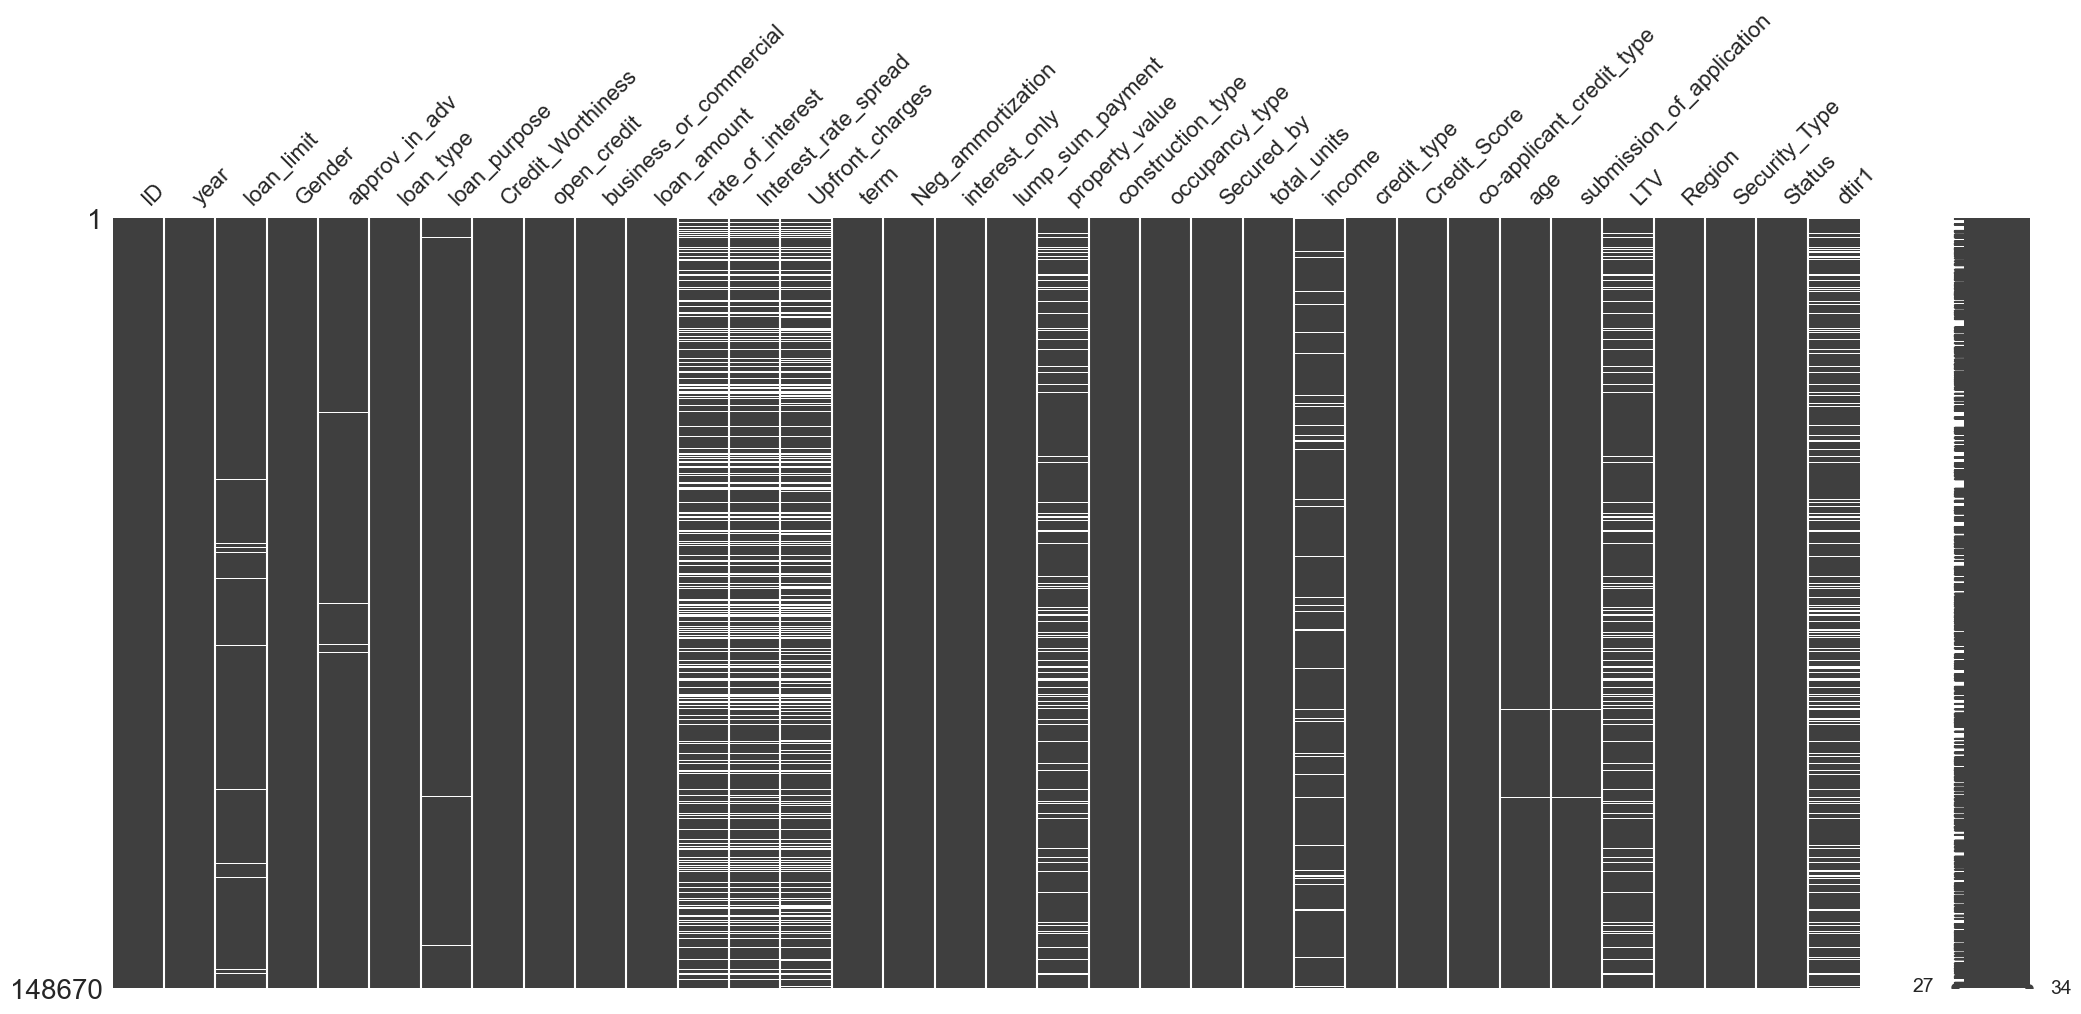

In [12]:
msno.matrix(df)
plt.show()

## Checking if loan status is dependant on gender

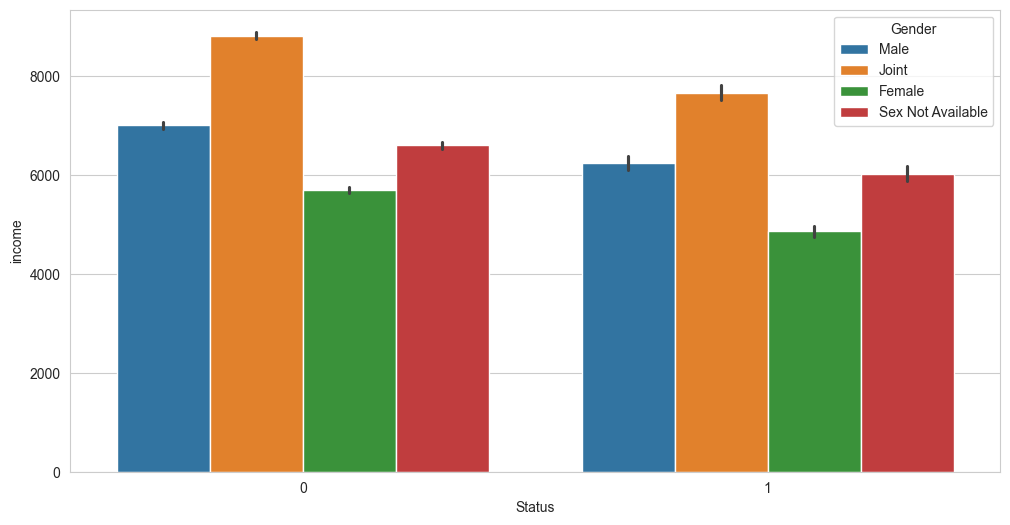

In [13]:
fig,ax=plt.subplots()
sns.barplot(data=df,x='Status',y='income',hue='Gender')
fig.set_size_inches([12,6])
plt.show()

In [14]:
df['Gender'].value_counts()

Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

## How loan defaulter is dependant to credit score and loan amount

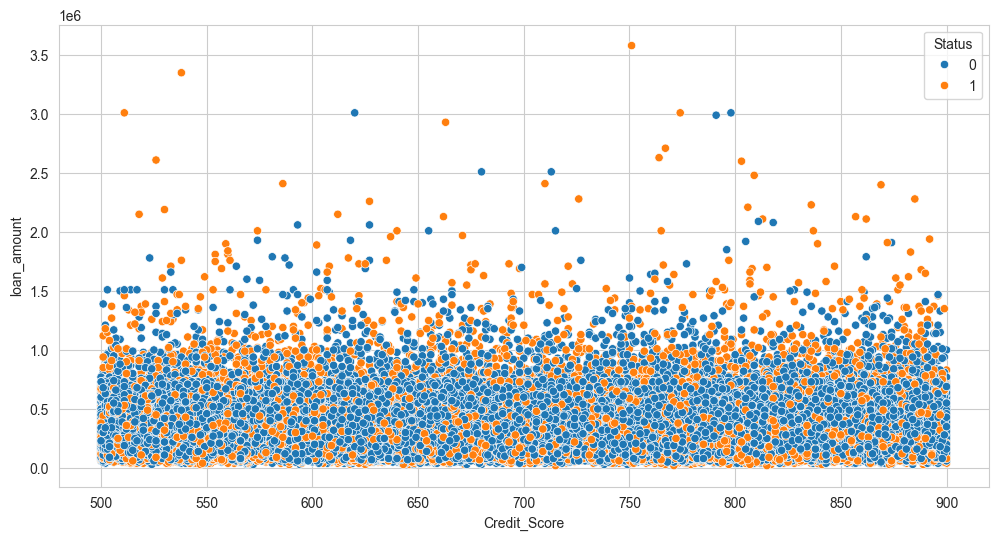

In [15]:
fig, ax=plt.subplots()
sns.scatterplot(data=df,x='Credit_Score', y='loan_amount', hue='Status')
fig.set_size_inches([12,6])
plt.show()

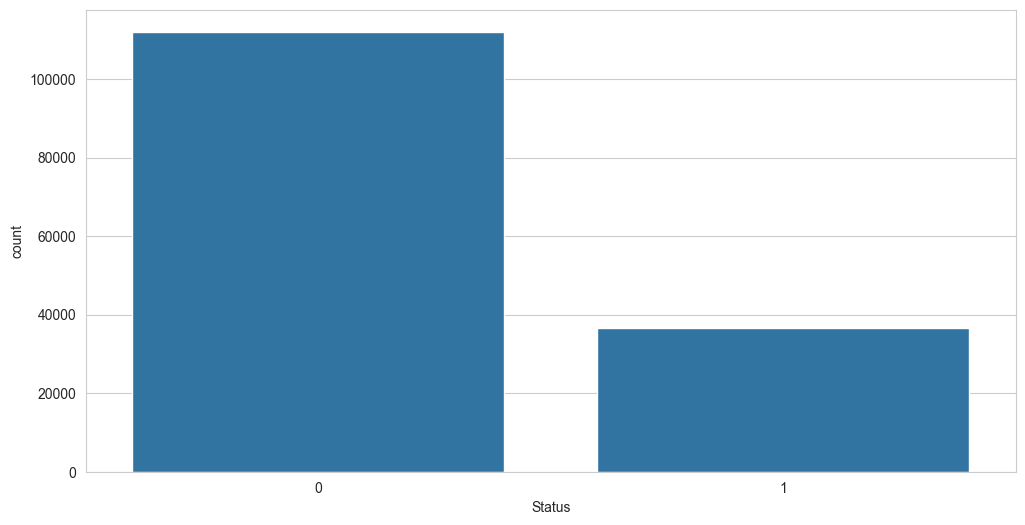

In [16]:
sns.countplot(x='Status', data=df)
plt.show()


- The dataset exhibits class imbalance, with a significantly higher proportion of non-default loans compared to default loans. This imbalance may cause the model to become biased toward predicting the majority class.

<Axes: xlabel='age', ylabel='count'>

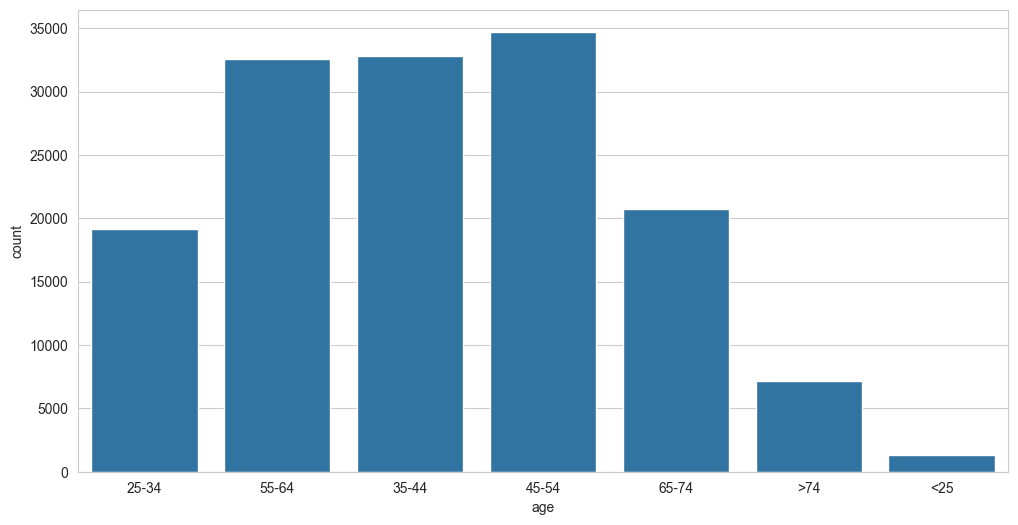

In [17]:
sns.countplot(data=df, x='age')

<Axes: xlabel='Status', ylabel='rate_of_interest'>

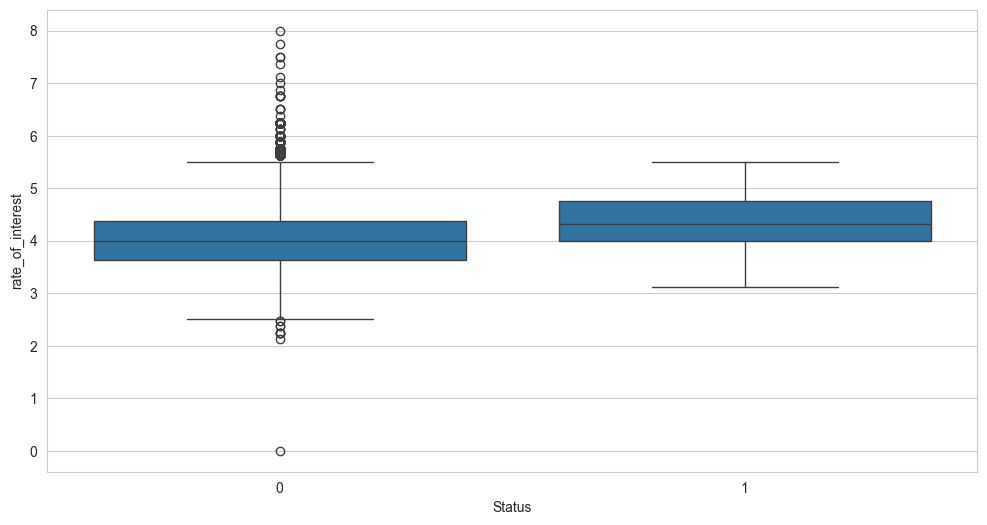

In [18]:
sns.boxplot(data=df, x="Status", y="rate_of_interest")


- The boxplot shows that defaulters tend to have slightly higher median interest rates compared to non-defaulters. However, significant overlap between the distributions indicates that interest rate alone is not sufficient to predict loan default.

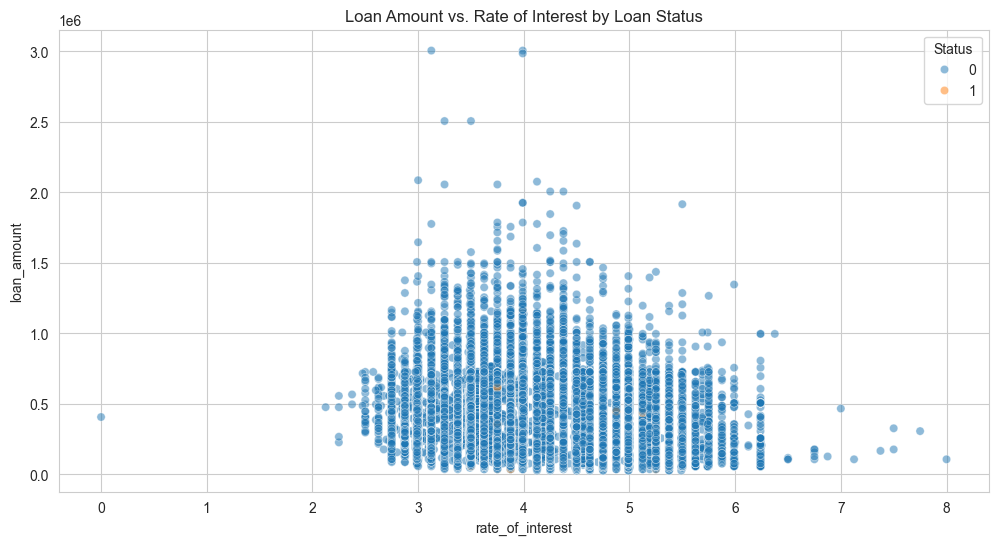

In [19]:
sns.scatterplot(
    data=df,
    x="rate_of_interest",
    y="loan_amount",
    hue="Status",
    alpha=0.5   # helps reduce overlap
)
plt.title("Loan Amount vs. Rate of Interest by Loan Status")
plt.show()

- The scatter plot reveals significant overlap between default and non-default loans across interest rate and loan amount, indicating that these variables alone do not provide strong class separation.

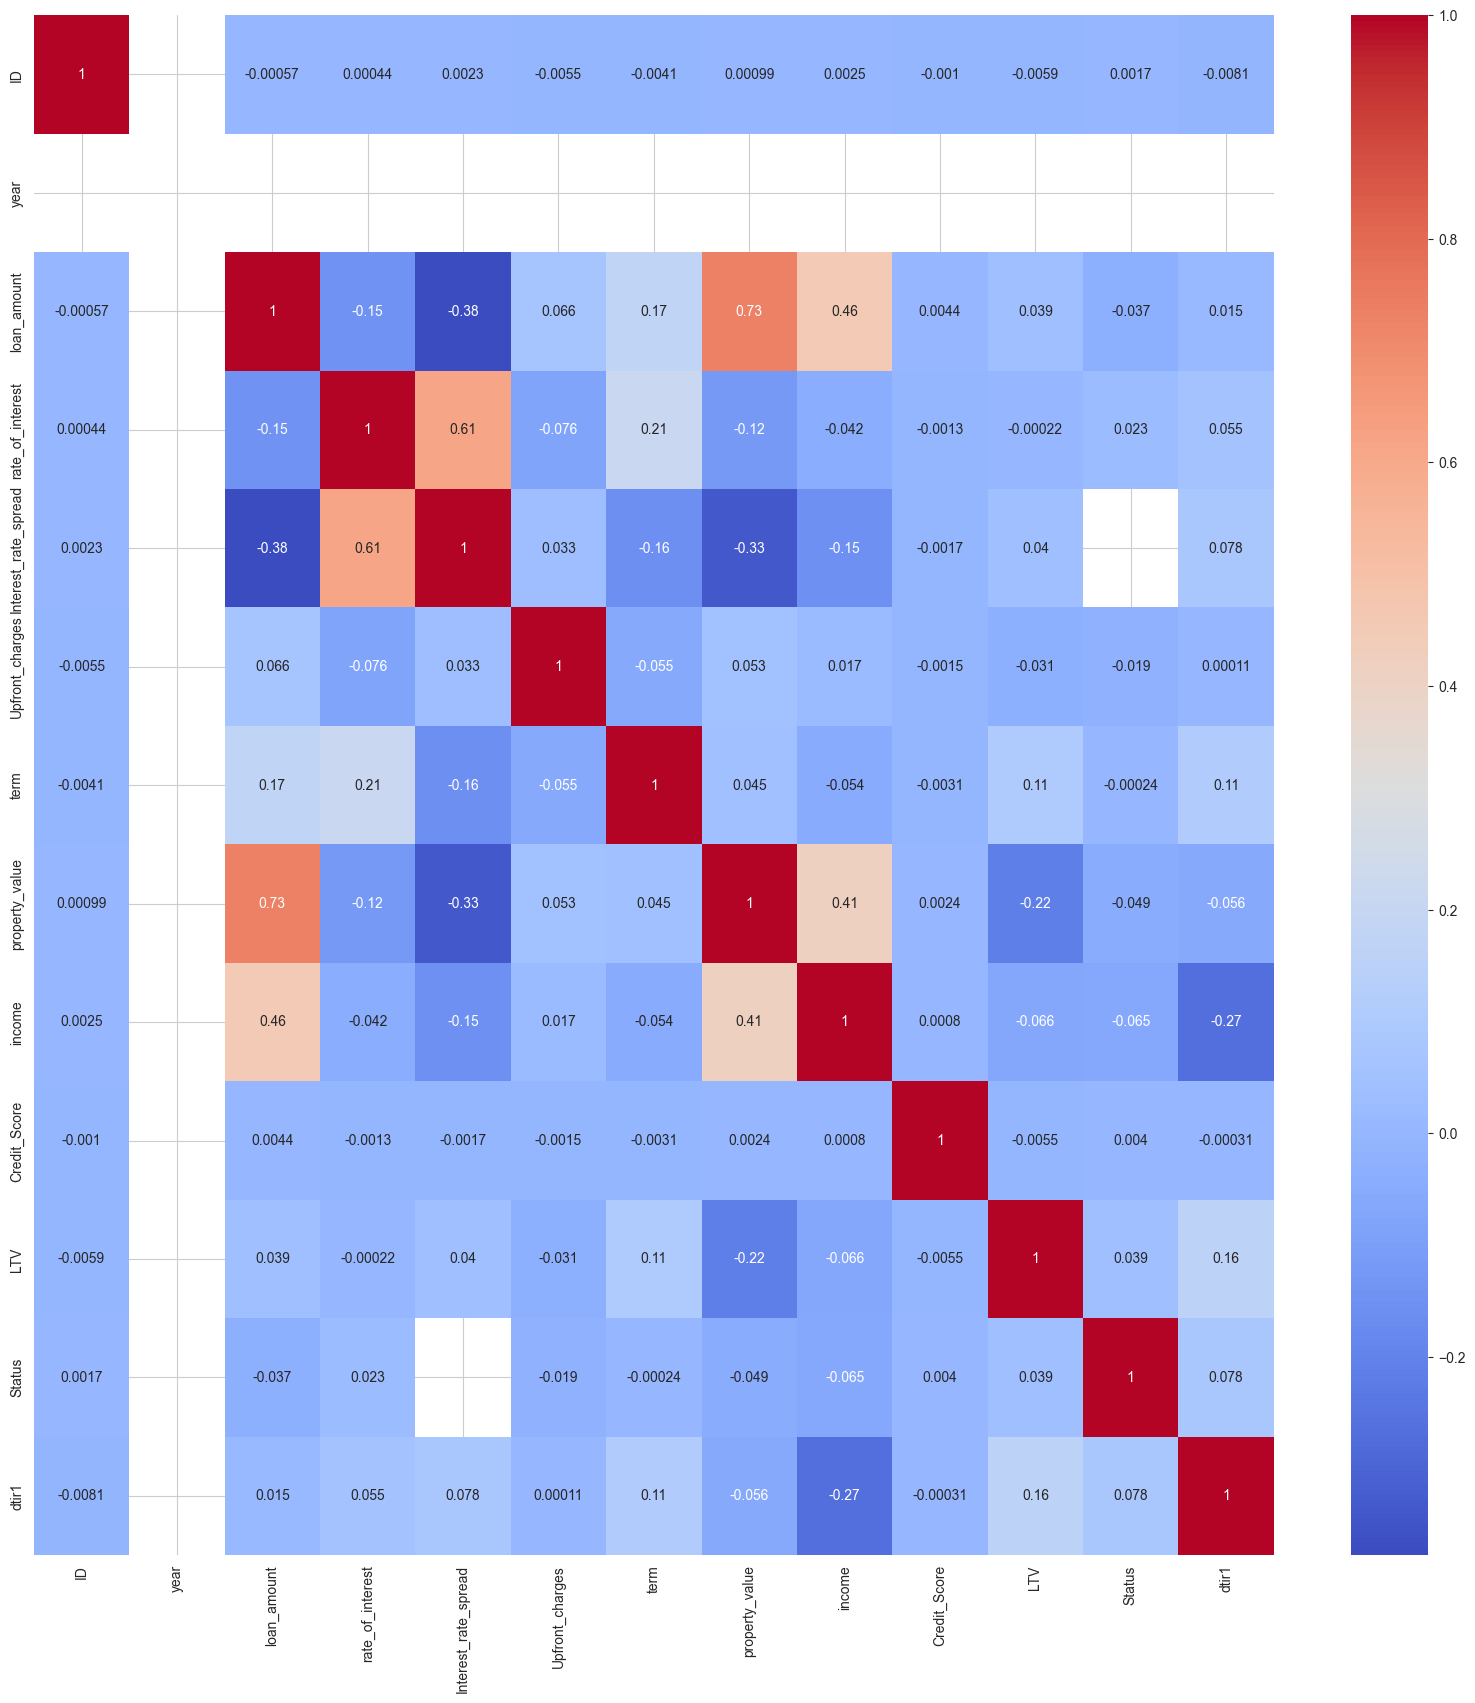

In [20]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


- The correlation heatmap indicates strong relationships among financial variables such as loan amount and property value (r=0.73). However, no single variable exhibits strong correlation with loan default status, suggesting that default prediction requires multi-feature modeling rather than reliance on individual predictors.

In [21]:
df = df.drop(columns=['year'])


- The year column contained a constant value (2019) across all records and was removed as it provides no predictive information.

In [22]:
df.head(5)

,ID,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
